# [WEEK 3] [Time Series] 과제

## 과제 목적

이번 과제는 세션에서 다룬 내용을 **하나의 데이터에 처음부터 끝까지 적용**해 보는 것을 목적으로 합니다.
`시계열 구성요소 확인 → 정상성 진단과 차분 → ACF/PACF로 차수 결정 → SARIMA → LSTM → DLinear → 평가·검증` 순서로 진행하며, **앞 단계의 결과가 뒤 단계의 입력이 되는 구조**입니다.
단순히 모델을 구현하는 데서 끝내지 않고, **완전히 동일한 평가 조건 위에서 성격이 다른 모델 세 가지를 비교하고 차이가 왜 발생했는지 해석**하는 데 초점을 둡니다.

---

### 사용 데이터: ETT (Electricity Transformer Dataset)

- **전력 변압기**에서 2016-07 ~ 2018-06까지 **1시간 간격**으로 수집한 데이터입니다. (17,420시점 × 7변수)
- 이 데이터는 세션에서 다룬 **LTSF-Linear / DLinear 논문이 사용한 벤치마크 데이터셋 중 하나**입니다.
  (데이터 원 출처는 `Informer, AAAI 2021` — https://arxiv.org/abs/2012.07436 )
- 저장소: https://github.com/zhouhaoyi/ETDataset

| 변수 | 의미 |
|---|---|
| HUFL / HULL | High UseFul Load / High UseLess Load |
| MUFL / MULL | Middle UseFul Load / Middle UseLess Load |
| LUFL / LULL | Low UseFul Load / Low UseLess Load |
| OT | Oil Temperature (변압기 유온) |

---
# 0. 환경 설정

In [ ]:
!pip install -q statsmodels

import warnings, hashlib, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [ ]:
# 데이터 로드 (ETDataset 저장소에서 직접 read)
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(URL, parse_dates=["date"]).set_index("date")
df = df.asfreq("h")          # 시간 단위 주기 명시

print("shape :", df.shape)
print("기간  :", df.index.min(), "~", df.index.max())
print("결측치 :", df.isna().sum().sum())
df.head()

shape : (17420, 7)
기간  : 2016-07-01 00:00:00 ~ 2018-06-26 19:00:00
결측치 : 0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


### 0-1. 본인 실험 조건 배정

`NAME` 에 **본인 이름**을 입력하세요. 이름을 해시해 **분석 대상 변수**와 **랜덤 시드**가 자동 배정됩니다.

> ⚠️ 이 값에 따라 이후 모든 결과가 달라집니다.

In [ ]:
NAME = "이윤지"       # TODO: 본인 이름 (예: "홍길동")

SEED   = int(hashlib.sha256(NAME.encode()).hexdigest(), 16) % 10000
COLS   = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
TARGET = COLS[SEED % 7]

np.random.seed(SEED); torch.manual_seed(SEED)

print(f"이름      : {NAME}")
print(f"SEED      : {SEED}")
print(f"분석 대상 : {TARGET}")

y = df[TARGET].astype(float)
print(f"\n시계열 길이: {len(y)},  결측: {y.isna().sum()}")
y.describe()

이름      : 이윤지
SEED      : 8080
분석 대상 : MUFL

시계열 길이: 17420,  결측: 0


,MUFL
count,17420.000000
mean,4.300239
std,6.826978
min,-25.087999
25%,3.296000
50%,5.970000
75%,8.635000
max,17.341000


---
# 1. 필수 과제

```
구성요소 확인 → 정상성 진단 → 차분 → 차수 결정 → 평가 프로토콜
   → 베이스라인 → SARIMA → LSTM → DLinear → 비교·해석
```

## 1-1. 시계열 구성 요소와 자기상관성

세션에서 시계열은 **추세 / 계절성 / 순환 / 잔차** 네 가지로 구성되고,
**자기상관성 · 정상성 · 변동성** 세 가지 특징을 갖는다고 배웠습니다.
실제 데이터에서 확인해 봅니다.

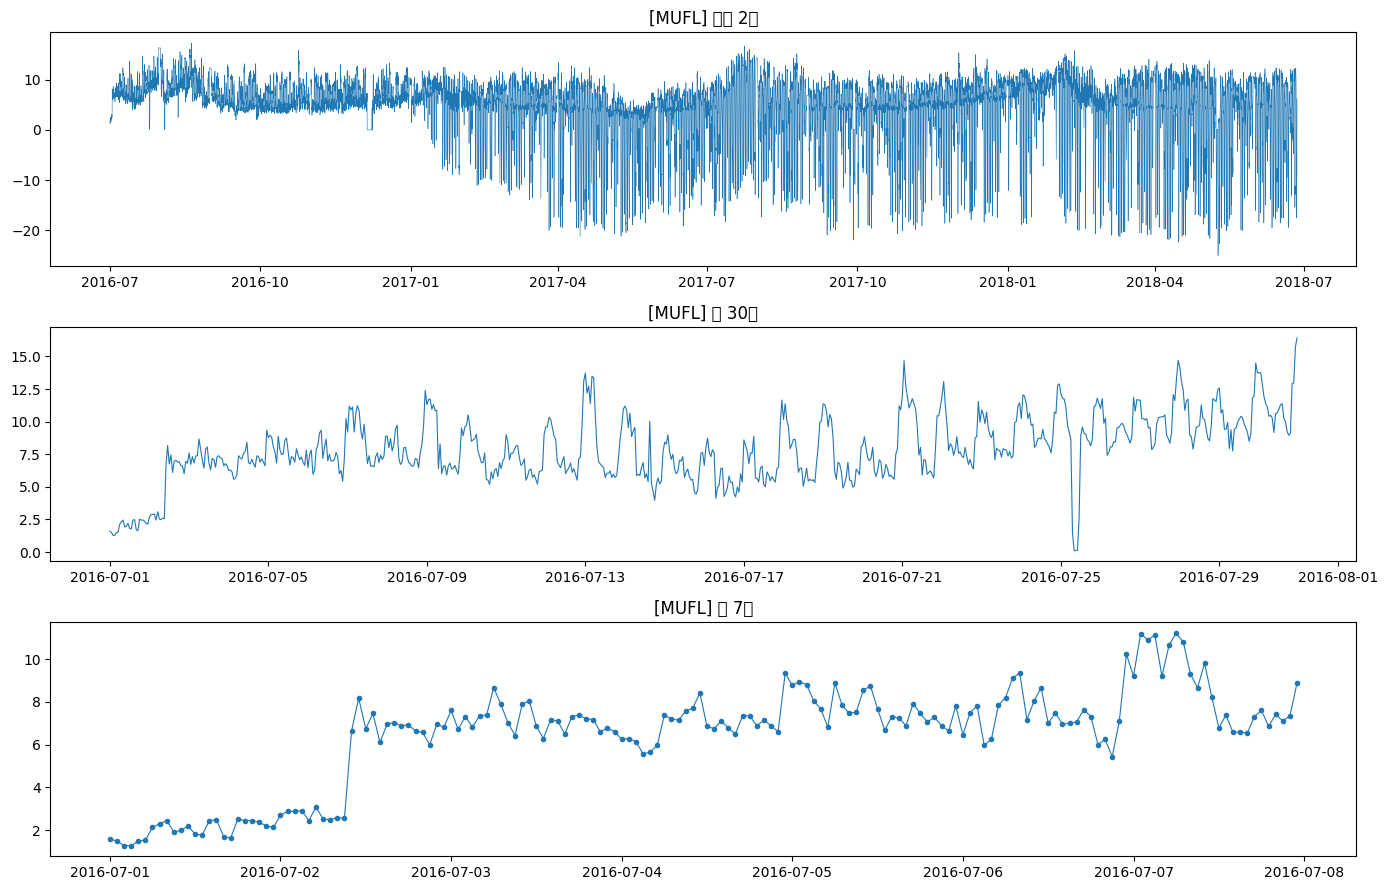

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(y.index, y.values, lw=0.4);                      axes[0].set_title(f"[{TARGET}] 전체 2년")
axes[1].plot(y.index[:24*30], y.values[:24*30], lw=0.8);      axes[1].set_title(f"[{TARGET}] 첫 30일")
axes[2].plot(y.index[:24*7], y.values[:24*7], marker=".", lw=0.8); axes[2].set_title(f"[{TARGET}] 첫 7일")
plt.tight_layout(); plt.show()

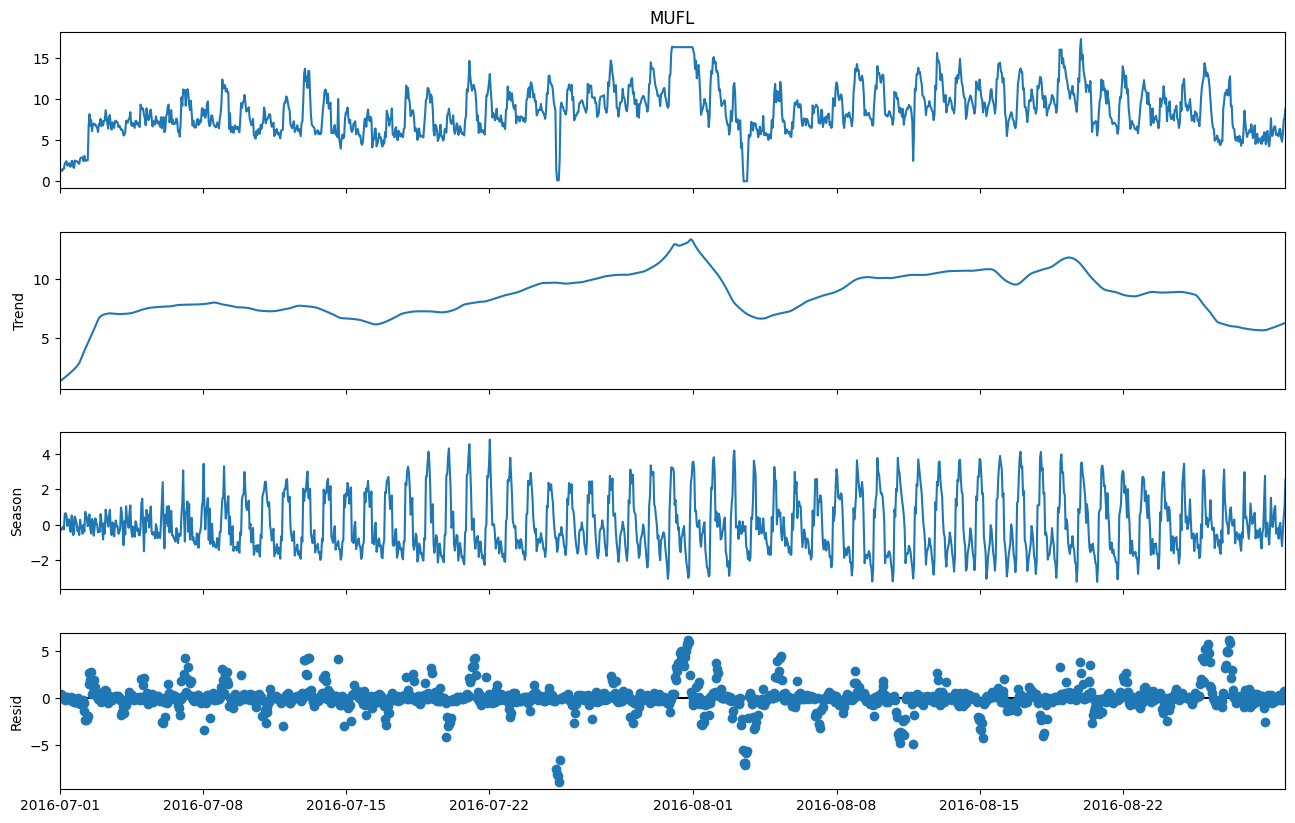

In [ ]:
# 구성요소를 눈으로 분리해 봅니다.
# TODO: 이 데이터는 '시간 단위'입니다. 하루 주기를 잡으려면 period에 무엇을 넣어야 할까요?
PERIOD = 24

fig = STL(y.iloc[:24*60], period=PERIOD, robust=True).fit().plot()
fig.set_size_inches(14, 9); plt.show()

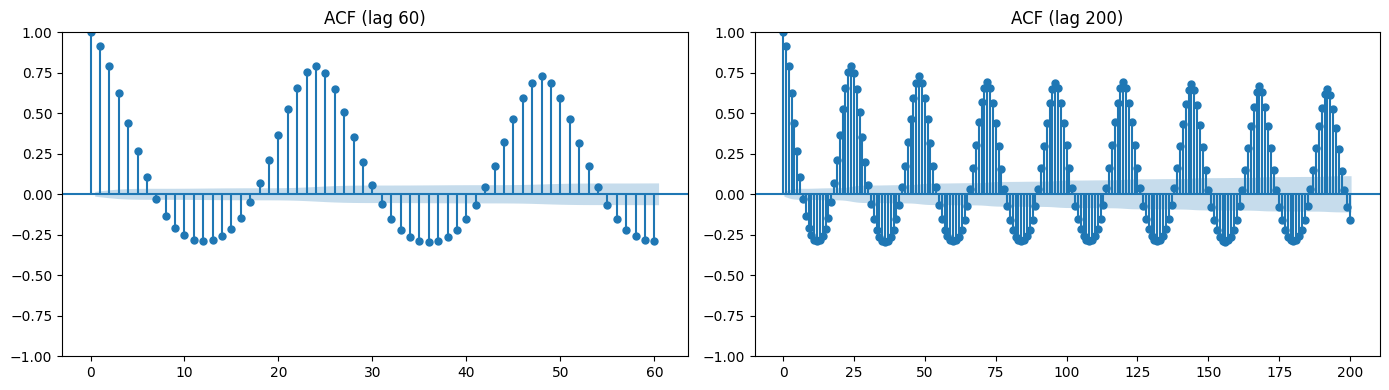

  ACF(lag=  1) = 0.918
  ACF(lag= 24) = 0.794
  ACF(lag= 48) = 0.728
  ACF(lag=168) = 0.666


In [ ]:
# 자기상관성 확인 : 며칠 전 값이 현재와 얼마나 닮아 있는가
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y.dropna(), lags=60,  ax=axes[0]); axes[0].set_title("ACF (lag 60)")
plot_acf(y.dropna(), lags=200, ax=axes[1]); axes[1].set_title("ACF (lag 200)")
plt.tight_layout(); plt.show()

def acf_at(s, lag):
    # ACF(k) = 시차 k만큼 떨어진 값들의 공분산 / 전체 분산
    x = np.asarray(s.dropna(), float)
    x = x - x.mean()                      # 평균을 빼서 편차로 변환

    # TODO: ACF 정의를 떠올려 분자(공분산 부분)를 완성하세요.
    #          x[lag:]는 t=lag+1..N 시점, x[:-lag]는 t=1..N-lag 시점입니다.
    numerator = (x[lag:] * x[:-lag]).sum()

    return numerator / (x * x).sum()      # 분모는 전체 분산

for lag in [1, 24, 48, 168]:
    print(f"  ACF(lag={lag:3d}) = {acf_at(y, lag):.3f}")

## 1-2. 정상성 진단 — ADF 검정

세션에서 배운 ADF 검정을 그대로 적용합니다.

| | 내용 |
|---|---|
| 귀무가설 | 단위근이 존재한다 → **비정상 시계열** |
| 대립가설 | 단위근이 존재하지 않는다 → **정상 시계열** |
| p-value < 0.05 | 귀무가설 기각 → **정상 시계열** |
| p-value ≥ 0.05 | 귀무가설 채택 → **비정상 시계열** |

In [ ]:
def adf_report(series, name):
    s = pd.Series(series).dropna()
    stat, p = adfuller(s)[0], adfuller(s)[1]

    # TODO: 세션에서 배운 ADF의 귀무가설을 떠올리며 부등호를 채우세요.
    verdict = "정상 시계열" if p < 0.05 else "비정상 시계열"

    print(f"[{name:16s}] ADF={stat:9.3f}  p={p:.4f}  ->  {verdict}")
    return p

adf_report(y, "원본")

[원본              ] ADF=   -8.621  p=0.0000  ->  정상 시계열


np.float64(6.098079311470388e-14)

> ### Q1.
> ADF 검정 결과 **원본 시계열이 "정상"** 으로 나왔을 것입니다.
> 그런데 1-1에서 그린 **ACF를 보면 lag 24, 48, 72마다 봉우리가 계속 반복**되고 있습니다.
>
> 1. "정상 시계열인데 자기상관이 강하게 남아 있다"는 것이 모순처럼 보입니다. 모순이 아닌 이유를 설명하세요.
>    (힌트: **자기상관성**과 **정상성**은 **서로 다른 특징**으로 소개되었습니다. 각각의 정의를 다시 확인해 보세요.)

정상성과 자기상관성은 서로 다른 것을 재는 개념이라 모순이 아니다. 정상성은 "시간이 흘러도 평균·분산·자기공분산 구조가 일정하게 유지되는가"라는 분포의 시간 불변성에 대한 성질이고, ADF 검정은 그중에서도 단위근이 있어 시계열이 발산하는지만 본다. 반면 자기상관성은 서로 다른 시점의 값이 얼마나 닮았는가를 재는 것으로, 시점 간 관계의 강도에 대한 성질이다. 즉 ADF는 자기상관이 없다를 검정하는 도구가 아니다. 자기상관이 0인 정상 시계열은 백색잡음뿐인데, 이는 정상 시계열의 아주 특수한 한 경우일 뿐이고 오히려 ARMA 계열 모형 자체가 정상이면서 자기상관을 갖는 시계열을 다루기 위해 만들어진 도구다. 실제 출력을 보면 ACF(1)=0.918, ACF(24)=0.794, ACF(48)=0.728, ACF(168)=0.666으로 값 자체는 매우 크지만 시차가 커질수록 꾸준히 줄어들고 있다. 단위근이 있는 비정상 시계열이라면 ACF가 거의 감소하지 않고 1 근처에 머무는데, 이 데이터는 감소하는 형태이므로 ADF가 p=0.0000으로 정상 판정을 내린 것과 일관된다. 정리하면 평균 수준이 특정 값 주위로 회귀하는 정상 시계열이지만, 그 안에 하루 주기의 강한 반복 구조를 갖고 있다가 정확한 해석이다.


> 2. 만약 ADF 결과만 보고 **"정상이니까 아무 처리 없이 바로 모델에 넣자"** 고 결론 내렸다면, 어떤 문제가 생길까요?

ADF가 통과했다는 것은 수준이 발산하지 않는다는 뜻일 뿐, 24시간 주기 구조가 사라졌다는 뜻이 전혀 아니다. 이 상태로 주기를 명시적으로 다루지 않는 모형(예: 계절항 없는 ARIMA)에 넣으면, 모형이 설명하지 못한 하루 주기가 잔차에 그대로 남는다. 잔차가 백색잡음이라는 가정이 깨지므로 계수의 표준오차가 과소추정되어 유의성 판단이 왜곡되고, 예측구간도 실제보다 좁게 나온다. 예측 성능 측면에서도 손해가 크다. 이번 과제는 24시간을 한 번에 예측하는데, 주기 정보를 쓰지 않는 Naive는 MAE 9.9433인 반면 24시간 전 값을 그대로 복사하기만 한 SeasonalNaive는 MAE 3.1486으로 3배 이상 좋았다. 즉 "정상성 검정 통과"와 "모델에 바로 넣어도 된다"는 별개의 판단이며, ADF 외에 ACF/PACF로 남아 있는 구조를 반드시 함께 확인해야 한다.


## 1-3. 차분(Differencing)

세션에서 **차분은 연이은 관측값들의 차이를 계산하는 것**이고, **추세나 계절성을 제거·감소**시킨다고 배웠습니다.

- **1차 차분** : $Y_t = X_t - X_{t-1}$
- **계절 차분** : $Y_t = X_t - X_{t-m}$  ($m$ = 계절 주기)

In [ ]:
y_diff1 = y.diff()          # 1차 차분

# TODO: 하루 주기를 제거하는 계절 차분을 만드세요. (힌트: .diff(?) )
y_seas  = y.diff(24)

print("=" * 60)
adf_report(y,       "원본")
adf_report(y_diff1, "1차 차분")
adf_report(y_seas,  "계절 차분(lag 24)")
print("=" * 60)

[원본              ] ADF=   -8.621  p=0.0000  ->  정상 시계열
[1차 차분           ] ADF=  -33.375  p=0.0000  ->  정상 시계열
[계절 차분(lag 24)   ] ADF=  -25.141  p=0.0000  ->  정상 시계열


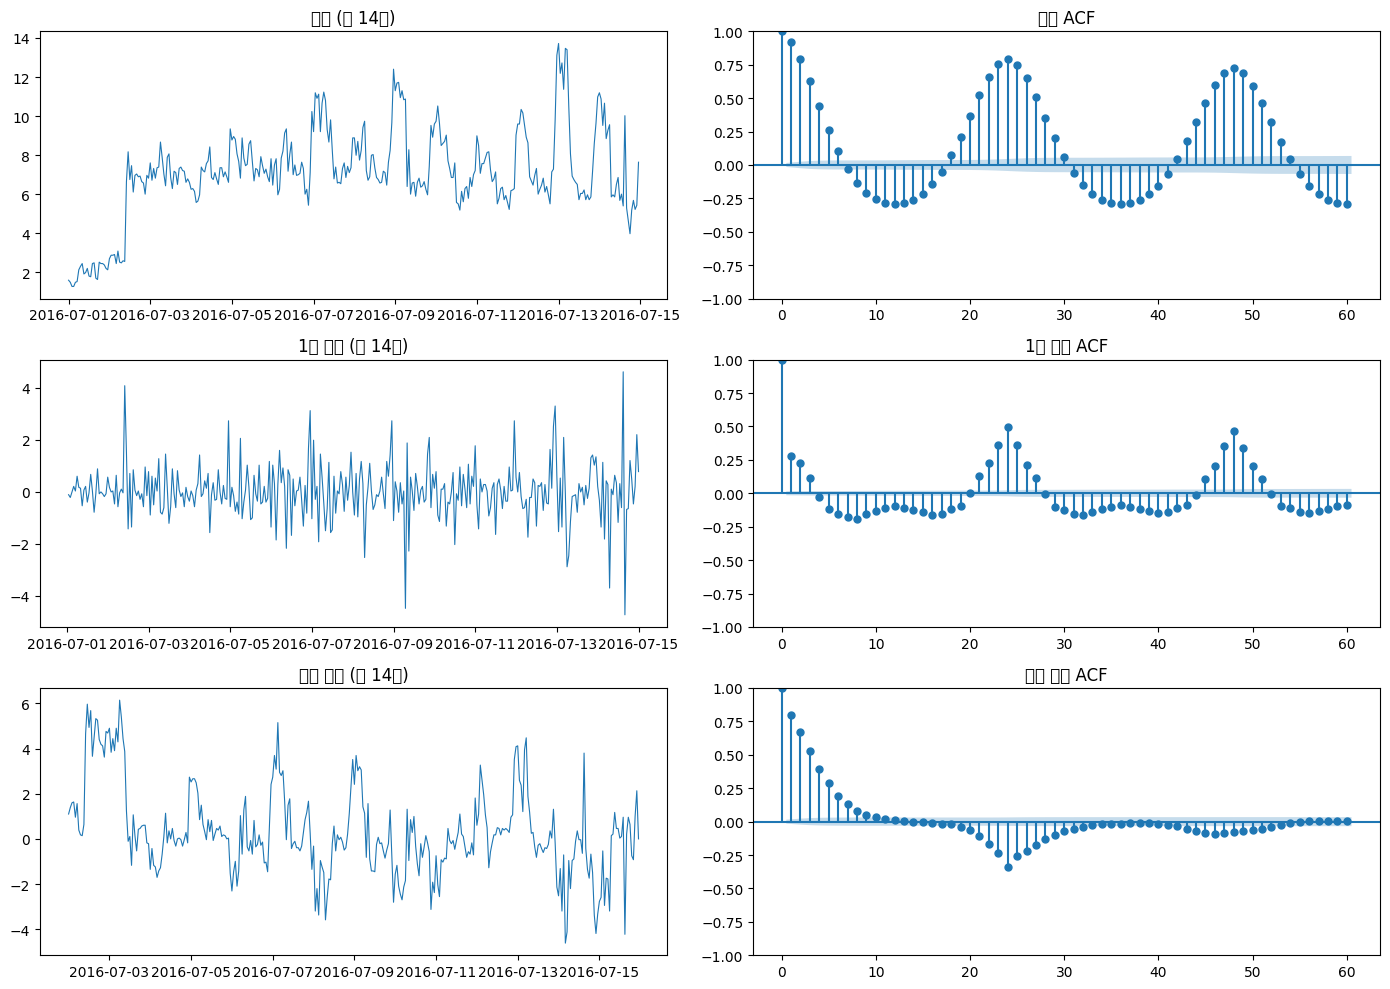

  원본           ACF(24) =   0.794
  1차 차분        ACF(24) =   0.498
  계절 차분        ACF(24) =  -0.339


In [ ]:
# '차분 전 / 후' ACF를 비교합니다.
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, (s, name) in enumerate([(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]):
    s_ = s.dropna()
    axes[i, 0].plot(s_.index[:24*14], s_.values[:24*14], lw=0.8); axes[i, 0].set_title(f"{name} (앞 14일)")
    plot_acf(s_, lags=60, ax=axes[i, 1]);                          axes[i, 1].set_title(f"{name} ACF")
plt.tight_layout(); plt.show()

for s, name in [(y, "원본"), (y_diff1, "1차 차분"), (y_seas, "계절 차분")]:
    print(f"  {name:12s} ACF(24) = {acf_at(s, 24):7.3f}")

> ### Q2.
> 1. **계절 차분 후** ACF의 lag 24 값이 0 근처가 아니라 **음수로 크게** 나왔을 것입니다. 세션에서 차분의 목적은 "정상 시계열로 바꾸는 것"이었는데, 이 결과는 차분이 잘 된 것이라고 볼 수 있나요? 근거와 함께 쓰세요.

잘 된 차분이라고 보기 어렵다. 과대차분(over-differencing)의 전형적인 신호다. 출력값을 보면 ACF(24)가 원본 0.794 → 1차 차분 0.498 → 계절 차분 -0.339로 변했다. 절대값만 보면 계절 차분이 가장 0에 가깝지만, 핵심은 부호가 양수에서 음수로 뒤집혔다는 점이다. 차분의 목적은 남아 있는 구조를 제거해 ACF를 0 근처로 보내는 것인데, 여기서는 제거를 넘어 원래 없던 음의 상관을 인위적으로 만들어냈다. 원본이 이미 ADF=-8.621, p=0.0000으로 정상 판정을 받은 상태였기 때문에 정상화를 위한 차분은 애초에 필요하지 않았고, 필요 없는 차분을 한 번 더 적용한 결과 X_t - X_{t-24} 형태의 MA 구조가 강제로 생긴 것이다. 과대차분은 잔차 분산을 키우고 불필요한 MA 항을 추가해 모형을 복잡하게 만들며 추정을 불안정하게 하므로 피해야 한다.


> 2. 위 결과를 종합해, 1-7에서 사용할 SARIMA의 **차분 차수 d 와 계절 차분 차수 D** 를 결정하고 근거를 서술하세요.

D = 0으로 결정했다. 위에서 확인했듯 계절 차분은 ACF(24)를 -0.339로 뒤집는 과대차분이었고, 원본이 이미 정상이므로 계절 차분으로 주기를 없애는 대신 seasonal_order의 P=1, Q=1로 24시간 주기를 모형 안에서 직접 설명하게 하는 편이 낫다.

d = 1로 결정했다. ADF만 보면 d=0도 가능하지만, ACF가 0.918 → 0.794 → 0.728 → 0.666으로 lag 168까지도 0.6대를 유지할 만큼 지속성이 매우 강해 국소적으로는 수준이 계속 이동하는 성격을 보인다. 특히 이번 과제의 SARIMA는 전체 구간이 아니라 각 origin 직전 1000시간만 잘라 rolling window로 적합하기 때문에, 그 짧은 구간 안에서는 사실상 수준 이동이 있는 시계열처럼 보인다. 실제로 1차 차분 후 ADF는 -8.621에서 -33.375로 훨씬 강해졌고 ACF(24)도 0.794에서 0.498로 줄어 남은 구조가 계절항으로 설명 가능한 범위로 정리되었다. 따라서 최종적으로 SARIMA(2,1,1)(1,0,1,24)를 사용했으며, 비계절 p=2, q=1은 1차 차분 계열의 PACF가 초반 시차 이후 빠르게 줄어드는 형태를 반영한 것이다.

## 1-4. ACF / PACF로 차수 결정

세션에서 배운 판별표입니다.

| 확률과정 | ACF | PACF |
|---|---|---|
| **AR(p)** | 지수적으로 감소하거나 감쇠 사인파 형태 | **시차 p 이후 0으로 절단** |
| **MA(q)** | **시차 q 이후 0으로 절단** | 지수적으로 감소하거나 감쇠 사인파 형태 |
| **ARMA(p,q)** | 절단 없이 감소 | 절단 없이 감소 |

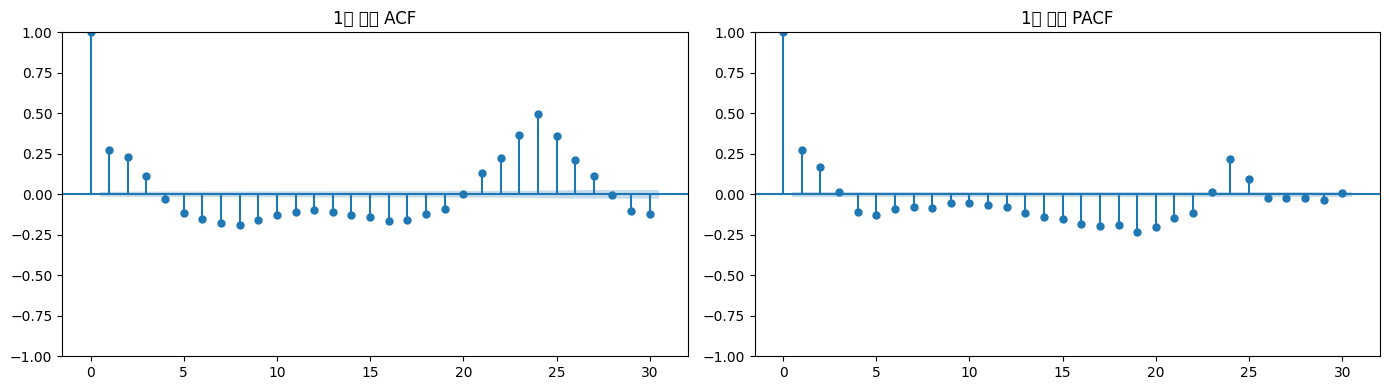

In [ ]:
s_ = y_diff1.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s_,  lags=30, ax=axes[0]); axes[0].set_title("1차 차분 ACF")
plot_pacf(s_, lags=30, ax=axes[1]); axes[1].set_title("1차 차분 PACF")
plt.tight_layout(); plt.show()

In [ ]:
# TODO: Q2의 판단 결과와 위 ACF/PACF 그림을 반영하세요.
P_ORDER  = 2             # 비계절 AR 차수 p
D_ORDER  = 1             # 차분 차수 d
Q_ORDER  = 1             # 비계절 MA 차수 q
SEASONAL = (1, 0, 1, 24) # (P, D, Q, m)

print(f"SARIMA{(P_ORDER, D_ORDER, Q_ORDER)}{SEASONAL}")

SARIMA(2, 1, 1)(1, 0, 1, 24)


## 1-5. 평가 프로토콜 설계 — Time-Based Split

**여기가 이번 과제에서 가장 중요한 부분입니다.**
서로 다른 모델을 비교하려면 **완전히 동일한 조건**에서 평가해야 합니다.

세션에서 배운 **Time-Based Split** 을 사용합니다. 과거 데이터를 학습에, 이후 시점을 테스트에 쓰는 방식입니다.

| 항목 | 값 |
|---|---|
| Lookback (입력 길이 L) | 168시간 (= 1주) |
| Horizon (예측 길이 H) | 24시간 (= 1일) |
| 분할 | 시간순 train 70% / val 10% / test 20% |
| 평가 지점(origin) | test 구간에서 균등하게 30개 |

In [ ]:
n = len(y)

# TODO: 시간순으로 70% / 80% 지점의 인덱스를 계산하세요.
i_train = int(n * 0.7)
i_val   = int(n * 0.8)

train, val, test = y[:i_train], y[i_train:i_val], y[i_val:]
L, H, M = 168, 24, 24        # lookback, horizon, 계절주기

for nm, s in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:6s} {len(s):6d}  ({s.index.min().date()} ~ {s.index.max().date()})")

train   12194  (2016-07-01 ~ 2017-11-21)
val      1742  (2017-11-21 ~ 2018-02-01)
test     3484  (2018-02-01 ~ 2018-06-26)


In [ ]:
# 모든 모델이 공유할 평가 지점(origin) 30개
N_ORIGIN = 30

# TODO: origin끼리 예측 구간(H시간)이 겹치지 않게 하려면 간격을 얼마로 둬야 할까요?
cand    = np.arange(i_val, n - H, H)
origins = cand[np.linspace(0, len(cand) - 1, N_ORIGIN).astype(int)]
Y_TRUE  = np.stack([y.values[t:t + H] for t in origins])   # (30, 24) 정답

print("origin 개수:", len(origins), "| 정답 행렬:", Y_TRUE.shape)
print("첫 origin :", y.index[origins[0]], "/ 끝 origin :", y.index[origins[-1]])

origin 개수: 30 | 정답 행렬: (30, 24)
첫 origin : 2018-02-01 16:00:00 / 끝 origin : 2018-06-25 16:00:00


### 평가 지표

세션에서 다룬 **MAE / RMSE / MAPE** 세 가지를 사용합니다.

| 지표 | 정의 |
|---|---|
| MAE | 오차의 절대값 평균 |
| RMSE | 오차 제곱 평균의 제곱근 |
| MAPE | 오차 비율의 평균 (%) |

In [ ]:
def score(name, pred):
    e    = Y_TRUE - pred
    mae  = np.mean(np.abs(e))

    # TODO: 세션의 정의를 보고 RMSE를 완성하세요.
    rmse = np.sqrt(np.mean(e ** 2))

    nz   = np.abs(Y_TRUE) > 1e-6                       # 0 나눗셈 방지
    mape = np.mean(np.abs(e[nz] / Y_TRUE[nz])) * 100
    return dict(model=name, MAE=mae, RMSE=rmse, MAPE=mape)

results = []
excluded = (1 - (np.abs(Y_TRUE) > 1e-6).mean()) * 100
print(f"MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = {excluded:.2f}%")
print(f"정답값 중 절대값 0.5 미만 비율          = {(np.abs(Y_TRUE) < 0.5).mean()*100:.2f}%")
print(f"정답값 중 음수 비율                     = {(Y_TRUE < 0).mean()*100:.2f}%   (최솟값 {Y_TRUE.min():.3f})")

MAPE 계산에서 제외된(실제값 0에 가까운) 비율 = 0.14%
정답값 중 절대값 0.5 미만 비율          = 1.81%
정답값 중 음수 비율                     = 26.53%   (최솟값 -21.250)


## 1-6. 베이스라인 만들기

> - **Naive** : "다음 24시간도 지금 값이랑 똑같을 것이다"
> - **Seasonal Naive** : "내일 09시 값 = 오늘 09시 값" (24시간 전 같은 시각을 그대로 복사)
>
> 이렇게 **아무 학습도 하지 않는 예측**을 먼저 만들어 두는 이유는, 나중에 나온 MAE 값이 좋은 건지 나쁜 건지 판단할 **기준선**이 필요하기 때문입니다.

In [ ]:
pred_naive  = np.stack([np.repeat(y.values[t - 1], H) for t in origins])

# TODO: Seasonal Naive를 구현하세요. 24시간 전 같은 시각부터 H시간을 그대로 가져옵니다.
pred_snaive = np.stack([y.values[t - M : t - M + H] for t in origins])

results.append(score("Naive",         pred_naive))
results.append(score("SeasonalNaive", pred_snaive))
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,MAPE
model,,,
Naive,9.9433,12.2659,204.9201
SeasonalNaive,3.1486,5.3135,90.1001


> ### Q3.
> 1. `Naive` 와 `SeasonalNaive` 의 성능 차이로부터 이 데이터의 어떤 성질을 알 수 있나요?
>    단, 1-1의 ACF 값을 다시 보면 **ACF(1)이 ACF(24)보다 큽니다.** "직전 값이 가장 닮았다"는 뜻인데 왜 `Naive`가 졌을까요?
>    (힌트: 이 과제는 1시간 뒤가 아니라 **24시간치를 한 번에** 예측합니다. `Naive`는 24시간 동안 무슨 값을 내놓나요?)

Naive는 MAE 9.9433, SeasonalNaive는 MAE 3.1486으로 SeasonalNaive가 3배 이상 좋았다. 이는 이 데이터에서 24시간 주기의 계절성이 예측에 가장 지배적인 정보라는 뜻이다. 학습을 전혀 하지 않고 하루 전 같은 시각 값을 복사하기만 해도 이 정도 성능이 나온다는 것은, 하루 단위 패턴이 그만큼 안정적으로 반복되고 있다는 근거다.

ACF(1)=0.918이 ACF(24)=0.794보다 큰데도 Naive가 진 이유는 예측 지평 때문이다. ACF(1)이 크다는 것은 "1시간 뒤"를 맞힐 때 직전 값이 가장 좋은 정보라는 뜻이지, 24시간 뒤까지 그렇다는 뜻이 아니다. 이 과제는 24시간치를 한 번에 예측하는데, Naive는 origin 직전 값 하나를 24번 반복하므로 24시간 내내 완전한 수평 직선을 내놓는다. MUFL은 하루 안에서 크게 오르내리고 정답값의 26.53%가 음수이며 최솟값이 -21.250일 만큼 진폭이 크기 때문에, 상수 직선은 하루치 변동을 통째로 놓친다. 반면 SeasonalNaive는 24시간 전 같은 시각부터 24시간을 복사하므로 하루 동안의 오르내리는 모양 자체를 그대로 가져온다. 즉 예측 지평이 길어질수록 직전 값 하나의 정보 가치는 급격히 떨어지고 주기 정보의 가치가 커진다는 것을 보여준다.



> 2. 앞으로 만들 SARIMA / LSTM / DLinear 가 **최소한 어떤 수치를 넘어야** 의미 있는 모델일까요? 구체적인 숫자로 답하세요.
>
> *(이 질문의 답은 1-10에서 모델 성능을 해석할 때 기준선으로 계속 사용됩니다.)*

기준선은 SeasonalNaive의 MAE 3.1486(RMSE 5.3135)이다. Naive의 MAE 9.9433은 학습하는 모델이라면 당연히 넘어야 하는 최소선이고, 실질적인 합격선은 SeasonalNaive다. 학습 파라미터를 갖고 시간을 들여 적합한 SARIMA/LSTM/DLinear가 MAE 3.1486보다 크다면, 그 모델은 24시간 전 값을 복사하는 것보다도 못한 것이므로 의미 있는 모델이라고 할 수 없다.

## 1-7. 모델 A — SARIMA

세션에서 배운 **Walk-Forward Validation** 을 그대로 적용합니다.
> 시간 순서를 유지하면서 예측 기준 시점을 순차적으로 이동시키며 **반복적으로 학습·예측·평가**를 수행

각 origin마다 **그 직전 1000시간만** 잘라 모델을 새로 적합하고 24시간을 예측합니다. (Rolling window 방식)

In [ ]:
WINDOW = 1000
t0, preds = time.time(), []

for i, t in enumerate(origins):
    # TODO: origin t 직전 WINDOW 시간만 잘라내세요. (미래가 절대 포함되면 안 됩니다)
    hist = y.values[t - WINDOW : t]

    m = SARIMAX(hist, order=(P_ORDER, D_ORDER, Q_ORDER), seasonal_order=SEASONAL,
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    # TODO: 앞으로 H시간을 예측하세요.
    preds.append(m.forecast(H))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(origins)}  ({time.time()-t0:.0f}s)")

pred_sarima = np.stack(preds)
results.append(score("SARIMA", pred_sarima))
print(f"\n총 소요 {time.time()-t0:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

  20/30  (91s)
  30/30  (170s)

총 소요 170초


,MAE,RMSE,MAPE
model,,,
Naive,9.9433,12.2659,204.9201
SeasonalNaive,3.1486,5.3135,90.1001
SARIMA,5.2675,6.6755,123.5532


  10/30  (36s)
  20/30  (92s)
  30/30  (171s)

총 소요 171초


,MAE,RMSE,MAPE
model,,,
Naive,9.9433,12.2659,204.9201
SeasonalNaive,3.1486,5.3135,90.1001
SARIMA,5.2675,6.6755,123.5532


## 1-8. 모델 B — LSTM

세션에서 RNN의 **기울기 소실** 문제와, 이를 완화하기 위한 **LSTM의 셀 상태 + 3개 게이트** 구조를 배웠습니다. 직접 학습시켜 봅니다.

### 스케일링

> ⚠️ **스케일러는 반드시 train 구간으로만 fit 해야 합니다.**
> 전체 데이터로 fit하면 train 시점에서는 알 수 없는 **미래의 평균·표준편차**가 흘러 들어갑니다.
> Walk-Forward에서 강조한 **Data Leakage** 가 여기서도 똑같이 발생합니다.

In [ ]:
# TODO: 평균과 표준편차를 어느 구간에서 계산해야 할까요?
mu, sd = train.mean(), train.std()

ys = ((y - mu) / sd).values.astype("float32")
print(f"정규화 기준  mu={mu:.4f}, sd={sd:.4f}")

def make_windows(lo, hi, L_=None):
    """[lo, hi) 구간에서 (입력 L, 정답 H) 쌍을 슬라이딩으로 생성"""
    L_ = L_ or L
    X, Y = [], []
    for t in range(lo + L_, hi - H + 1):
        X.append(ys[t - L_ : t]); Y.append(ys[t : t + H])
    return torch.tensor(np.array(X)), torch.tensor(np.array(Y))

X_tr, Y_tr = make_windows(0, i_train)
X_va, Y_va = make_windows(i_train, i_val)
X_te       = torch.tensor(np.stack([ys[t - L : t] for t in origins]))

print("train:", X_tr.shape, "| val:", X_va.shape, "| test:", X_te.shape)

정규화 기준  mu=4.5495, sd=6.1572
train: torch.Size([12003, 168]) | val: torch.Size([1551, 168]) | test: torch.Size([30, 168])
정규화 기준  mu=4.5495, sd=6.1572
train: torch.Size([12003, 168]) | val: torch.Size([1551, 168]) | test: torch.Size([30, 168])


In [ ]:
# 학습 곡선 보는 법
#   - train / val이 나란히 감소 후 수평   -> 적절
#   - train은 계속 감소하는데 val이 반등  -> 과적합
#   - 둘 다 높은 채로 안 내려감           -> 과소적합 (epoch/lr 조정 필요)

def train_model(model, X_tr, Y_tr, X_va, Y_va, epochs=15, bs=64, lr=1e-3, tag=""):
    model = model.to(DEVICE)
    opt, lossf = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, Y_tr), batch_size=bs, shuffle=True)

    history, best_val, best_state = {"train": [], "val": []}, float("inf"), None
    for ep in range(epochs):
        model.train(); total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vl = lossf(model(X_va.to(DEVICE)), Y_va.to(DEVICE)).item()
        history["train"].append(total / len(X_tr)); history["val"].append(vl)

        # TODO: train loss가 아니라 val loss가 가장 낮았던 시점의 모델을 저장해야 합니다.
        #          어떤 조건일 때 이 epoch의 모델을 best_state로 저장해야 할까요?
        if vl < best_val:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 5 == 0:
            print(f"  [{tag}] epoch {ep+1:3d}  train={history['train'][-1]:.5f}  val={vl:.5f}")
    model.load_state_dict(best_state)
    print(f"  [{tag}] best val loss = {best_val:.5f}  |  파라미터 {sum(p.numel() for p in model.parameters()):,d}")
    return model, history


def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X.to(DEVICE)).cpu().numpy() * sd + mu


def plot_curve(hist, title):
    plt.figure(figsize=(7, 3.5))
    plt.plot(hist["train"], label="train", marker="o", ms=3)
    plt.plot(hist["val"],   label="val",   marker="s", ms=3)
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

  [LSTM] epoch   5  train=0.28100  val=0.49503
  [LSTM] epoch  10  train=0.25371  val=0.46485
  [LSTM] epoch  15  train=0.24274  val=0.51864
  [LSTM] best val loss = 0.46485  |  파라미터 18,712


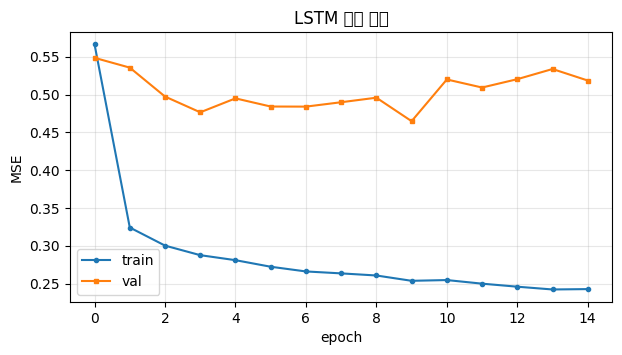

,MAE,RMSE,MAPE
model,,,
Naive,9.9433,12.2659,204.9201
SeasonalNaive,3.1486,5.3135,90.1001
SARIMA,5.2675,6.6755,123.5532
LSTM,3.3667,4.8474,78.0458


  [LSTM] epoch   5  train=0.28100  val=0.49503
  [LSTM] epoch  10  train=0.25371  val=0.46485
  [LSTM] epoch  15  train=0.24274  val=0.51864
  [LSTM] best val loss = 0.46485  |  파라미터 18,712


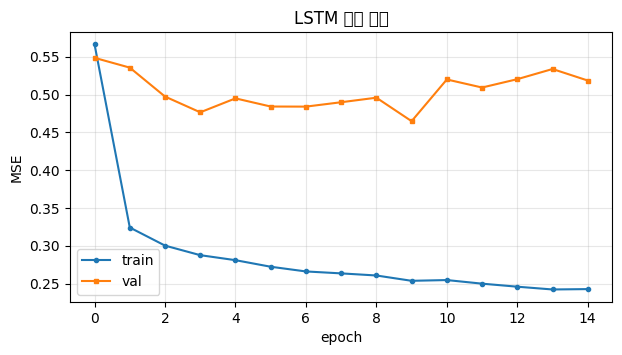

,MAE,RMSE,MAPE
model,,,
Naive,9.9433,12.2659,204.9201
SeasonalNaive,3.1486,5.3135,90.1001
SARIMA,5.2675,6.6755,123.5532
LSTM,3.3667,4.8474,78.0458


In [ ]:
class LSTMForecast(nn.Module):
    def __init__(self, H, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, H)

    def forward(self, x):                 # x: (B, L)
        out, _ = self.lstm(x.unsqueeze(-1))   # (B, L, hidden)
        # TODO: 168개 시점의 은닉 상태 중 예측에 사용할 것은 무엇일까요?
        #       (힌트: RNN 구조 그림에서 마지막 시점의 은닉 상태)
        return self.fc(out[:, -1])

torch.manual_seed(SEED)
t0 = time.time()
model_lstm, hist_lstm = train_model(LSTMForecast(H), X_tr, Y_tr, X_va, Y_va, tag="LSTM")
t_lstm = time.time() - t0
results.append(score("LSTM", predict(model_lstm, X_te)))
plot_curve(hist_lstm, "LSTM 학습 곡선")
pd.DataFrame(results).set_index("model").round(4)

## 1-9. 모델 C — LTSF-DLinear

세션에서 배운 DLinear의 3단계를 그대로 구현합니다.

```
(1) Moving Average로 데이터를 Trend(추세)와 Remainder(잔차) 성분으로 나눔
(2) 각 성분을 Linear 학습
(3) 두 레이어의 결과를 합하여 최종 예측값 생성          X̂ = H_s + H_t
```

  [DLinear] epoch   5  train=0.27323  val=0.44690
  [DLinear] epoch  10  train=0.26792  val=0.43311
  [DLinear] epoch  15  train=0.26711  val=0.43961
  [DLinear] best val loss = 0.42972  |  파라미터 8,112


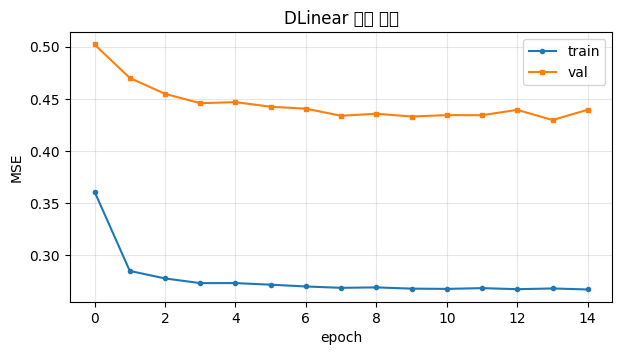

DLinear 학습 시간 11초


,MAE,RMSE,MAPE
model,,,
Naive,9.9433,12.2659,204.9201
SeasonalNaive,3.1486,5.3135,90.1001
SARIMA,5.2675,6.6755,123.5532
LSTM,3.3667,4.8474,78.0458
DLinear,3.2366,4.8197,82.1574


In [ ]:
class DLinear(nn.Module):
    def __init__(self, L, H, kernel=25):   # kernel은 반드시 홀수 (짝수면 출력 길이가 1 늘어남)
        super().__init__()
        self.kernel = kernel
        self.lin_trend     = nn.Linear(L, H)   # 추세 성분용
        self.lin_remainder = nn.Linear(L, H)   # 잔차 성분용

    def series_decomp(self, x):
        """(1) 이동평균으로 Trend를 뽑고, 원본에서 빼서 Remainder를 얻습니다."""
        pad_len = self.kernel // 2
        pad   = torch.cat([x[:, :1].repeat(1, pad_len), x, x[:, -1:].repeat(1, pad_len)], dim=1)
        trend = nn.functional.avg_pool1d(pad.unsqueeze(1), self.kernel, stride=1).squeeze(1)

        remainder = x - trend
        return remainder, trend

    def forward(self, x):
        remainder, trend = self.series_decomp(x)
        # (3) 두 Linear의 출력을 더해서 최종 예측(H 길이)을 만듭니다.
        out = self.lin_trend(trend) + self.lin_remainder(remainder)
        return out

torch.manual_seed(SEED)
t0 = time.time()
model_dl, hist_dl = train_model(DLinear(L, H), X_tr, Y_tr, X_va, Y_va, tag="DLinear")
t_dl = time.time() - t0
results.append(score("DLinear", predict(model_dl, X_te)))
plot_curve(hist_dl, "DLinear 학습 곡선")
print(f"DLinear 학습 시간 {t_dl:.0f}초")
pd.DataFrame(results).set_index("model").round(4)

## 1-10. 성능 비교 및 해석

**완전히 동일한 30개 origin**에서 다섯 가지 예측을 비교합니다.

,MAE,RMSE,MAPE
model,,,
SeasonalNaive,3.1486,5.3135,90.1001
DLinear,3.2366,4.8197,82.1574
LSTM,3.3667,4.8474,78.0458
SARIMA,5.2675,6.6755,123.5532
Naive,9.9433,12.2659,204.9201


,MAE,개선율(%)
model,,
SeasonalNaive,3.1486,0.00
DLinear,3.2366,-2.79
LSTM,3.3667,-6.93
SARIMA,5.2675,-67.30
Naive,9.9433,-215.80


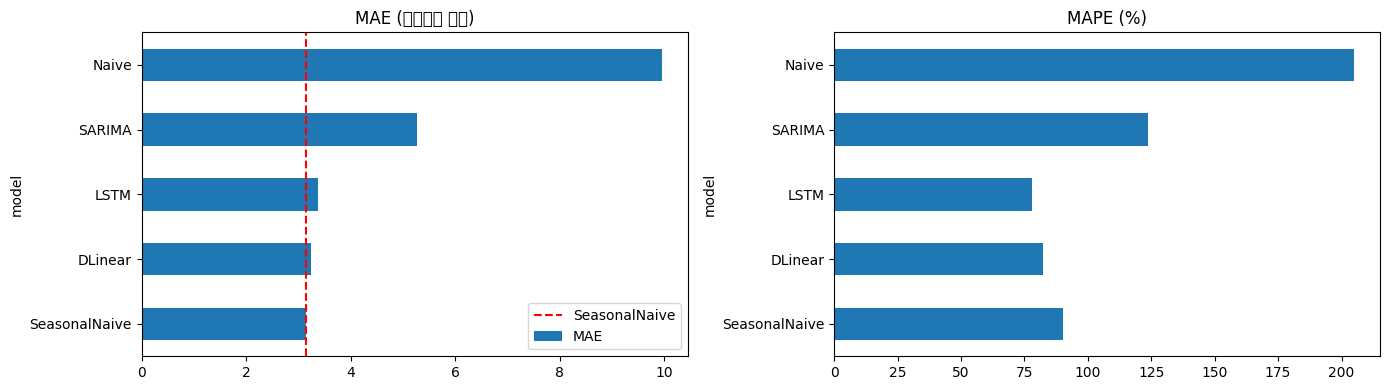

In [ ]:
res = pd.DataFrame(results).set_index("model").sort_values("MAE").round(4)
display(res)

base = res.loc["SeasonalNaive", "MAE"]
res["개선율(%)"] = ((base - res["MAE"]) / base * 100).round(2)   # 베이스라인 대비
display(res[["MAE", "개선율(%)"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
res["MAE"].plot(kind="barh", ax=axes[0], title="MAE (낮을수록 좋음)")
axes[0].axvline(base, color="red", ls="--", label="SeasonalNaive"); axes[0].legend()
res["MAPE"].plot(kind="barh", ax=axes[1], title="MAPE (%)")
plt.tight_layout(); plt.show()

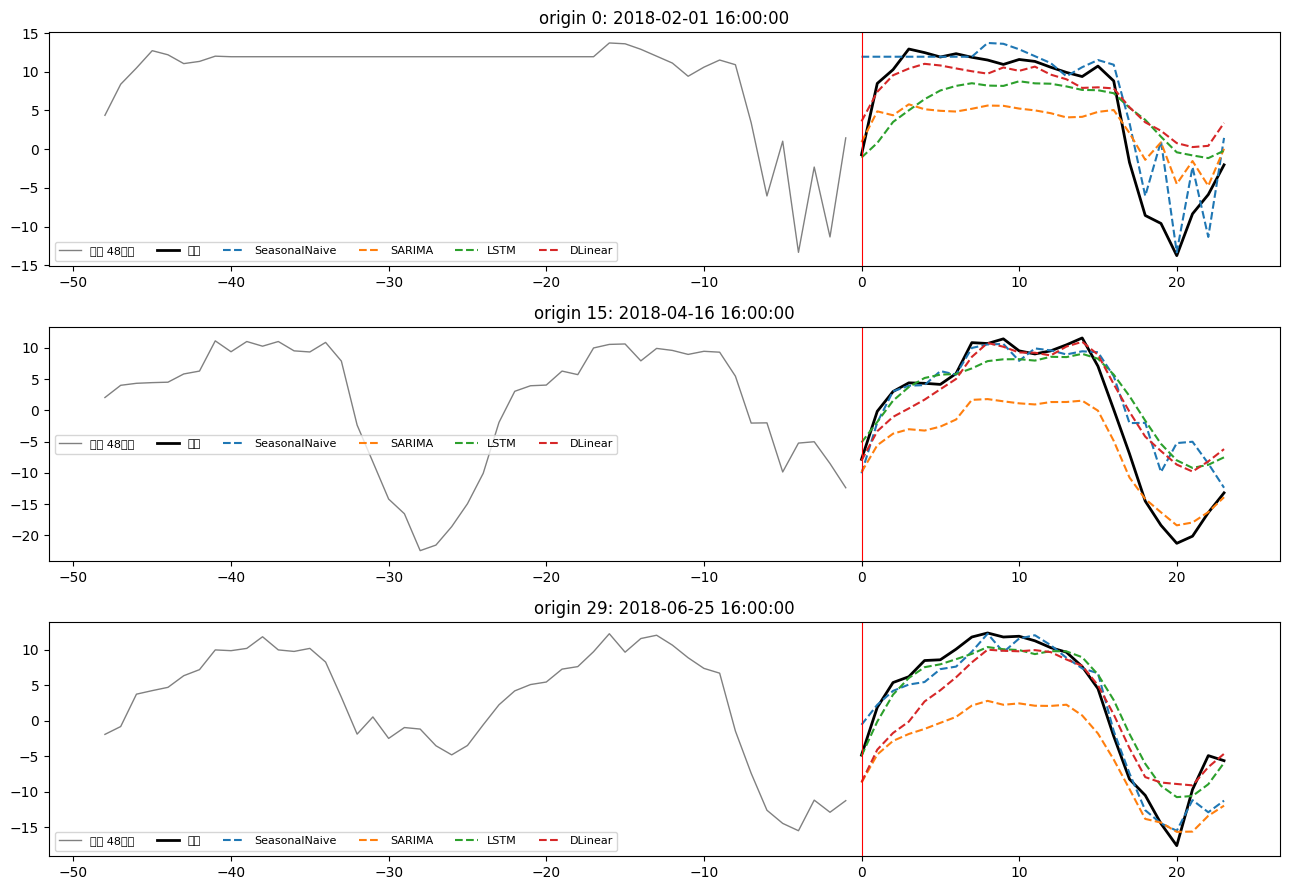

In [ ]:
pred_dl, pred_lstm = predict(model_dl, X_te), predict(model_lstm, X_te)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, k in zip(axes, [0, len(origins)//2, len(origins)-1]):
    t = origins[k]
    ax.plot(range(-48, 0), y.values[t-48:t], color="gray", lw=1, label="과거 48시간")
    ax.plot(range(H), Y_TRUE[k],      "k-", lw=2, label="실제")
    ax.plot(range(H), pred_snaive[k], "--", label="SeasonalNaive")
    ax.plot(range(H), pred_sarima[k], "--", label="SARIMA")
    ax.plot(range(H), pred_lstm[k],   "--", label="LSTM")
    ax.plot(range(H), pred_dl[k],     "--", label="DLinear")
    ax.axvline(0, color="red", lw=.8); ax.set_title(f"origin {k}: {y.index[t]}")
    ax.legend(fontsize=8, ncol=6)
plt.tight_layout(); plt.show()

> ### Q4. 왜 이러한 결과가 나왔는가?
> 순위를 나열하지 말고, **데이터의 성질과 각 모델의 구조를 연결**해서 설명하세요.


이 데이터의 가장 강한 신호는 24시간 주기다. ACF(24)=0.794로 하루 전 같은 시각과의 상관이 매우 높고, 학습을 전혀 하지 않는 SeasonalNaive가 MAE 3.1486으로 SARIMA(5.2675)를 포함한 여러 모델을 앞선 것이 그 증거다. 반대로 직전 값 하나를 24시간 동안 반복하는 Naive는 MAE 9.9433으로 압도적으로 나빴다. 즉 "직전 값"이 아니라 "하루 전 같은 시각의 24시간 모양"을 얼마나 잘 재현하느냐가 이 과제의 성패를 갈랐고, 각 모델의 구조가 이 정보를 얼마나 직접적으로 쓸 수 있는지가 순위를 결정했다.

SARIMA가 개선율 -67.30%로 가장 크게 실패한 이유는 구조적 제약 때문이다. 첫째, 각 origin 직전 1000시간(약 41일)만 잘라 rolling window로 적합하기 때문에 하루 주기를 관측할 표본이 41번뿐이고, 그 짧은 구간의 국소적 특성에 과하게 맞춰진다. 둘째, 계절 구조 전체를 seasonal_order의 P=1, Q=1 단 두 개 파라미터로 설명해야 한다. 하루 24시간의 복잡한 파형을 계수 두 개로 압축하는 것은 불가능에 가깝다. 셋째, d=1 차분 구조상 예측 지평이 길어질수록 예측값이 마지막 관측값을 기준으로 한 완만한 경로로 수렴한다. RMSE/MAE 비율을 보면 SARIMA는 1.27로 Naive의 1.23과 거의 같은데, 이는 SARIMA의 오차 분포가 "상수에 가까운 예측"인 Naive와 성격이 비슷하다는 뜻이다. 결국 SARIMA는 24시간 앞을 볼 때 Naive의 실패 방식을 완화한 형태로 반복했다.

LSTM(3.3667)과 DLinear(3.2366)는 학습을 통해 SeasonalNaive에 근접했지만 MAE 기준으로는 넘지 못했다. 다만 RMSE에서는 각각 4.8474, 4.8197로 SeasonalNaive의 5.3135를 약 9% 앞섰고, MAPE에서도 78.0458, 82.1574로 90.1001을 앞섰다. 이 역전이 핵심이다. SeasonalNaive의 RMSE/MAE 비율은 1.69로 다섯 모델 중 가장 높은데, 이는 평소에는 매우 정확하지만 어제와 오늘의 패턴이 어긋나는 날에는 큰 오차를 낸다는 뜻이다. 반면 DLinear는 1.49, LSTM은 1.44로 비율이 낮아, 전형적인 오차는 조금 크지만 치명적으로 빗나가는 경우가 적다. 학습 모델은 168시간 전체를 보고 "어제를 그대로 믿을지 말지"를 조절할 수 있기 때문이다.

DLinear가 LSTM보다 나은 이유는 예측 방식의 차이다. LSTM은 168개 시점을 순차적으로 처리한 뒤 마지막 은닉 상태 하나(64차원)만 Linear에 넘긴다. 168스텝의 정보를 64차원 벡터 하나로 압축해야 하므로 앞쪽 시점의 정보가 희석되는 병목이 생긴다. 반면 DLinear는 168개 입력에서 24개 출력으로 가는 직접적인 선형 사상이라, 출력 시점마다 "168시간 전 구간의 어느 위치를 얼마나 참고할지"에 대한 가중치를 따로 학습한다. 즉 "24시간 전 같은 시각"이라는 SeasonalNaive의 규칙 자체를 가중치로 학습한 뒤 미세 조정할 수 있는 구조다. 여기에 이동평균으로 Trend와 Remainder를 분리해 각각 학습하므로, 수준 변화와 주기 변동을 분리해 다룰 수 있다. 파라미터는 8,112개로 LSTM의 18,712개보다 훨씬 적고 학습 시간도 11초에 불과했다. 데이터의 핵심 구조가 주기적 선형 관계일 때는 복잡한 비선형 모형보다 구조를 잘 반영한 단순 선형 모형이 유리하다는 LTSF-Linear 논문의 주장과 일치하는 결과다.



> ### Q5. 세 모델의 성능 차이는 어디에서 발생했는가?
> 위 예측 곡선 그림을 근거로, **어떤 상황에서 어느 모델이 유리했는지** 구체적으로 짚으세요.
> (힌트: 평탄한 구간 / 급변 구간 / 예측 시점에서 먼 뒤쪽 시간대를 나눠서 보세요)


예측 곡선 그림을 구간별로 나눠 보면 성능 차이가 어디서 발생했는지 드러난다. 예측 시점 직후 몇 시간에서는 SARIMA를 포함한 모든 모델이 실제값과 비교적 가깝게 붙어 있지만, 예측 시점에서 멀어질수록 SARIMA의 예측선이 하루치 진폭을 따라가지 못하고 완만한 곡선으로 평탄해지며 실제값과 크게 벌어진다. 반면 SeasonalNaive는 24시간 내내 실제값과 같은 모양의 굴곡을 유지하고, DLinear와 LSTM은 실제값의 오르내리는 형태는 따라가되 봉우리와 골짜기의 진폭이 실제보다 다소 눌려 있는 완만한 곡선을 그린다.

평탄한 구간에서는 SeasonalNaive가 가장 유리하다. 어제와 오늘의 패턴이 그대로 반복되므로 복사만으로 오차가 거의 발생하지 않고, 이것이 MAE 3.1486이라는 가장 낮은 값의 원천이다. 학습 모델은 여러 날의 평균적 패턴을 학습하기 때문에 오히려 진폭이 평균 쪽으로 눌려 약간의 오차가 꾸준히 생기고, 이 차이가 MAE에서 DLinear -2.79%, LSTM -6.93%의 열세로 나타났다.

급변 구간에서는 관계가 뒤집힌다. 어제와 오늘의 패턴이 어긋나는 날 SeasonalNaive는 잘못된 모양을 그대로 24시간 내내 복사하므로 오차가 크게 누적된다. 이 성질은 RMSE에서 명확히 드러난다. SeasonalNaive의 RMSE는 5.3135로 MAE의 1.69배인데, DLinear는 4.8197로 1.49배, LSTM은 4.8474로 1.44배다. RMSE는 오차를 제곱해 평균하므로 큰 오차에 훨씬 민감한데, SeasonalNaive만 유독 이 비율이 높다는 것은 평소에는 정확하지만 간헐적으로 크게 빗나간다는 뜻이다. 실제로 RMSE 기준 순위는 DLinear(4.8197) < LSTM(4.8474) < SeasonalNaive(5.3135)로 완전히 역전된다. 학습 모델은 168시간 전체 문맥을 보고 최근 흐름이 어제와 다르면 예측을 조정할 수 있기 때문에 이런 날에 덜 무너진다.

예측 시점에서 먼 뒤쪽 시간대에서는 SARIMA와 나머지의 격차가 가장 크게 벌어진다. SARIMA는 자기회귀 구조상 예측을 순차적으로 이어가므로 h가 커질수록 정보가 소진되어 완만한 경로로 수렴하는 반면, DLinear와 LSTM은 24시간을 한 번에 출력하는 direct multi-step 방식이라 h=24 지점에도 h=1과 동일한 크기의 전용 가중치가 할당된다. 이 구조 차이가 SARIMA의 MAE 5.2675와 DLinear의 3.2366이라는 큰 격차로 이어졌다.

정리하면, SeasonalNaive는 평탄한 날의 전형적 오차를 줄이는 데 강하고(MAE 우위), DLinear와 LSTM은 어긋나는 날의 대형 오차를 막는 데 강하며(RMSE, MAPE 우위), SARIMA는 긴 예측 지평에서 구조적으로 불리했다.

> ### Q6. 예상과 다른 결과가 나왔다면 그 원인은 무엇인가?
> 1. 실험 전 예상과 실제 결과가 달랐던 지점을 하나 이상 쓰고 원인을 분석하세요.

가장 예상과 달랐던 것은 학습하는 세 모델 중 어느 것도 MAE 기준으로 SeasonalNaive를 넘지 못했다는 점이다. 개선율은 DLinear -2.79%, LSTM -6.93%, SARIMA -67.30%로 전부 음수였다. 파라미터를 학습하고 시간을 들인 모델이 24시간 전 값을 복사하기만 한 규칙보다 못하다는 것은 처음에 예상하지 못한 결과였다.

원인은 두 가지다. 첫째, 이 데이터의 24시간 주기가 그만큼 강력하고 안정적이어서 SeasonalNaive라는 베이스라인 자체가 강했다. ACF(24)=0.794라는 값이 이를 뒷받침한다. 둘째, 그럼에도 "졌다"는 결론은 MAE 하나만 본 판단이다. RMSE에서는 DLinear 4.8197, LSTM 4.8474로 SeasonalNaive의 5.3135를 약 9% 앞섰고, MAPE에서도 LSTM 78.0458, DLinear 82.1574로 90.1001을 앞섰다. 지표에 따라 우승자가 바뀌는 상황이므로 "학습 모델이 실패했다"가 아니라 "학습 모델은 큰 오차를 줄였고 대신 평소 오차가 약간 늘었다"가 정확한 해석이다.

두 번째로 예상과 달랐던 것은 SARIMA의 부진이다. 통계 기반의 정교한 모형이므로 최소한 SeasonalNaive는 넘을 것으로 기대했으나 MAE 5.2675로 크게 뒤졌다. 1000시간 window에 계절 파라미터 2개(P=1, Q=1)만으로 하루 주기 전체를 설명해야 하는 구조적 한계, 그리고 24시간이라는 긴 예측 지평에서 자기회귀 예측이 완만한 경로로 수렴하는 성질이 원인이다. 30개 origin을 적합하는 데 171초가 걸렸는데, DLinear는 11초 만에 학습하고도 훨씬 좋은 성능을 냈다는 점에서 비용 대비 효율도 크게 뒤졌다.

세 번째는 학습 곡선이다. LSTM은 train loss가 0.28100(5ep) → 0.25371(10ep) → 0.24274(15ep)로 계속 내려가는데 val loss는 0.49503 → 0.46485 → 0.51864로 10ep 이후 반등했다. 전형적인 과적합 신호이며 best val loss 0.46485인 10ep 시점의 가중치가 저장되었다. DLinear는 val loss가 0.44690 → 0.43311 → 0.43961로 훨씬 안정적이었고 best 0.42972로 LSTM보다 낮았다. 파라미터가 8,112개로 LSTM의 절반 이하라 과적합 여지가 작았기 때문이다. 다만 두 모델 모두 train loss(0.24~0.27)와 val loss(0.43~0.50)의 격차가 크게 유지되는데, 이는 단순 과적합만이 아니라 구간 자체의 성격 차이 때문으로 보인다. train은 2016-07~2017-11로 여름을 포함한 긴 구간인 반면 val은 2017-11~2018-02의 겨울 구간이고, 정규화에 쓴 mu=4.5495, sd=6.1572도 train 구간에서만 계산했기 때문에 val 구간의 수준과 변동폭이 다르면 정규화된 loss가 구조적으로 높게 나올 수밖에 없다.


> 2. **MAPE 값이 유독 크게 나왔을 수 있습니다.** 1-5에서 출력한 통계(0에 가까운 값의 비율, **음수 비율**)와 연결해 원인을 설명하고, 세션에서 배운 세 지표 중 **이 데이터에서는 무엇을 주로 봐야 하는지** 근거와 함께 제시하세요.
>    (힌트: MAPE는 오차를 실제값으로 나눕니다. 실제값이 **음수**이면 그 결과를 "오차율"이라고 부를 수 있을까요?)


MAPE는 Naive 204.9201%, SARIMA 123.5532%, SeasonalNaive 90.1001%로 비정상적으로 컸다. 오차율이 100%를 넘는다는 것은 "예측이 실제보다 자기 자신만큼 더 틀렸다"는 뜻인데, 이는 지표 자체가 이 데이터에 맞지 않다는 신호다.

원인은 1-5에서 출력한 통계에 그대로 나와 있다. 첫째, 정답값 중 음수 비율이 26.53%이고 최솟값이 -21.250이다. MAPE는 오차를 실제값으로 나누는데, 실제값이 음수이면 나눗셈의 부호가 뒤집혀 "오차율"이라는 해석 자체가 성립하지 않는다. 코드에서는 절대값을 씌워 계산하므로 숫자는 나오지만, 그 숫자를 백분율 오차로 읽을 근거가 사라진다. MAPE는 본래 매출이나 수요처럼 값이 항상 양수인 데이터를 전제로 만들어진 지표인데, 이 데이터는 그 전제를 26.53%나 위반한다. 둘째, 정답값 중 절대값 0.5 미만인 비율이 1.81%다. 분모가 0에 가까워지면 오차가 조금만 있어도 비율이 폭발적으로 커지고, 그 소수의 지점이 평균 전체를 끌어올린다. MAPE 계산에서 아예 제외된(절대값 1e-6 이하) 비율은 0.14%에 불과하므로, 0 근처의 값들이 제외되지 않고 대부분 계산에 들어갔다는 점도 확인된다.

따라서 이 데이터에서는 MAPE를 주 지표로 삼으면 안 되고, MAE와 RMSE를 함께 봐야 한다. MAE는 오차를 원 데이터와 같은 단위로 해석할 수 있고 실제값의 부호나 크기에 영향을 받지 않아 이 데이터의 주 지표로 적합하다. 다만 MAE만 보면 큰 오차와 작은 오차를 동등하게 취급하므로, 오차를 제곱해 큰 오차에 가중치를 주는 RMSE를 반드시 병기해야 한다. 이번 실험이 그 필요성을 정확히 보여준다. MAE 기준 1위는 SeasonalNaive(3.1486)지만 RMSE 기준 1위는 DLinear(4.8197)로 결론이 뒤집히며, 이 차이가 곧 "평소 오차가 작은 모델"과 "치명적 오차가 적은 모델"의 구분이다. 변압기 유온·부하 관리처럼 큰 오차 한 번이 위험한 상황이라면 RMSE를, 전체 평균적 정확도가 중요하다면 MAE를 우선하는 식으로 목적에 따라 선택해야 한다.

---
# 2. 심화 과제

아래 2개 중 **최소 1개 이상** 수행하세요. 코드는 대부분 채워져 있으니 **결과 해석**에 집중하면 됩니다.

| | 주제 | 세션 | 확인하려는 것 |
|---|---|---|---|
| **심화 A** | Time-Based Split vs Walk-Forward 비교 | 06장 | 평가 구간을 어떻게 잡느냐로 결론이 바뀌는가 |
| **심화 B** | lookback 길이를 바꿔 가며 DLinear 재학습 | 05장 | 과거를 길게 볼수록 항상 좋아지는가 |

## 심화 A. 검증 전략 비교

같은 모델을 두 방식으로 평가하면 성능 추정치가 얼마나 달라지는지 확인합니다.

- **Time-Based Split** : test 구간의 **맨 앞 origin 1개**에서만 평가 (세션의 "단일 테스트 구간")
- **Walk-Forward** : 30개 origin 전체에서 평가

Time-Based Split (origin 1개) MAE = 3.8421
Walk-Forward     (origin 30개) MAE = 3.2366
origin별 MAE  최소 1.2981 / 최대 5.7605 / 표준편차 1.0307


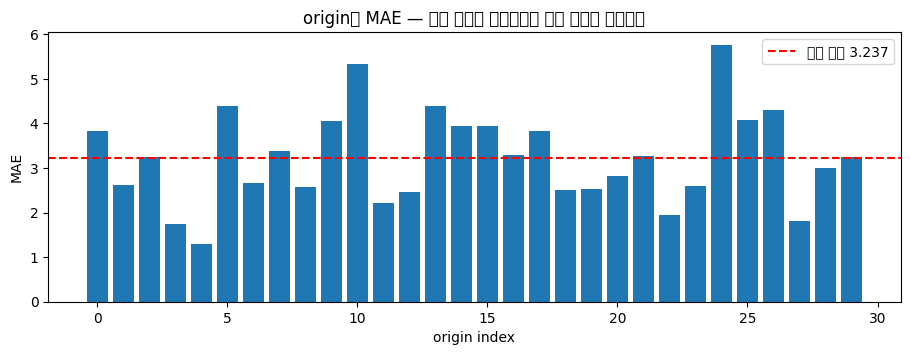

In [ ]:
p = predict(model_dl, X_te)
per_origin = np.abs(Y_TRUE - p).mean(axis=1)

# TODO: "Time-Based Split"은 test 구간에서 origin을 딱 1개(맨 처음)만 골라 평가하는 방식입니다.
#       per_origin 배열에서 그 origin의 결과는 어떻게 가져와야 할까요?
single_mae = per_origin[0]

print(f"Time-Based Split (origin 1개) MAE = {single_mae:.4f}")
print(f"Walk-Forward     (origin 30개) MAE = {per_origin.mean():.4f}")
print(f"origin별 MAE  최소 {per_origin.min():.4f} / 최대 {per_origin.max():.4f} / 표준편차 {per_origin.std():.4f}")

plt.figure(figsize=(11, 3.5))
plt.bar(range(len(per_origin)), per_origin)
plt.axhline(per_origin.mean(), color="red", ls="--", label=f"전체 평균 {per_origin.mean():.3f}")
plt.xlabel("origin index"); plt.ylabel("MAE"); plt.legend()
plt.title("origin별 MAE — 어느 구간을 고르느냐에 따라 결론이 달라진다")
plt.show()

- 선택: 심화 A (Time-Based Split vs Walk-Forward 비교)

- 실험 결과: 동일한 DLinear 모델을 두 방식으로 평가했을 때, test 구간 맨 앞 origin 하나만 사용하는 Time-Based Split은 MAE 3.8421, 30개 origin 전체를 사용하는 Walk-Forward는 MAE 3.2366이 나왔다. origin별 MAE는 최소 1.2981, 최대 5.7605, 표준편차 1.0307이었다.

- 해석: 같은 모델, 같은 가중치인데 평가 구간을 어떻게 잡느냐에 따라 성능 추정치가 크게 달라졌다. 단일 origin 추정치 3.8421은 30개 평균 3.2366보다 18.7% 높아 모델을 실제보다 나쁘게 평가했다. 더 심각한 것은 변동 폭이다. 최대 5.7605는 최소 1.2981의 4.4배이고, 표준편차 1.0307은 평균 대비 31.8%에 달한다. 만약 운 좋게 origin 하나만 골랐다면 MAE 1.2981이라는 결과를 보고 이 모델이 SeasonalNaive(3.1486)를 압도한다고 결론 내렸을 것이고, 반대로 나쁜 origin을 골랐다면 5.7605를 보고 SARIMA(5.2675)보다도 못하다고 결론 내렸을 것이다. 실제로 이번에 뽑힌 첫 origin의 3.8421은 SeasonalNaive보다 나쁜 값이라, 단일 구간 평가만 했다면 "DLinear는 베이스라인에 크게 못 미친다"는 잘못된 결론에 도달했을 것이다.

이런 변동이 생기는 이유는 시계열 데이터의 성격이 구간마다 다르기 때문이다. test 구간은 2018-02-01부터 2018-06-26까지 약 5개월로 겨울에서 초여름까지 걸쳐 있어, 어떤 origin은 패턴이 안정적인 시기이고 어떤 origin은 변동이 큰 시기다. 단일 구간 평가는 이 중 한 시점의 우연한 특성을 모델의 실력으로 착각하게 만든다.

결론적으로 시계열 모델을 평가할 때 단일 test 구간 성능만 보고하는 것은 위험하며, Walk-Forward로 여러 origin에 대해 반복 평가한 평균과 함께 표준편차나 최소·최대 범위를 반드시 보고해야 결과의 신뢰성을 판단할 수 있다. 이번 과제에서 30개 origin을 모든 모델이 공유하도록 설계한 것도 같은 이유다.

## 심화 B. lookback 길이 실험

LTSF-Linear 계열은 **입력 구간(lookback)을 얼마나 주느냐**에 성능이 민감합니다. 직접 확인해 봅니다.

In [ ]:
# TODO: 서로 다른 lookback 길이를 실험해 보세요. (예: 24, 96, 168, 336)
LOOKBACKS = [24, 96, 168, 336]

rows = []
for L_try in LOOKBACKS:
    Xa, Ya = make_windows(0, i_train, L_try)
    Xb, Yb = make_windows(i_train, i_val, L_try)
    Xc     = torch.tensor(np.stack([ys[t - L_try : t] for t in origins]))

    torch.manual_seed(SEED)
    m, _ = train_model(DLinear(L_try, H), Xa, Ya, Xb, Yb, epochs=15, tag=f"L={L_try}")
    s = score(f"L{L_try}", predict(m, Xc))
    rows.append({"lookback": L_try, "MAE": s["MAE"], "RMSE": s["RMSE"]})

pd.DataFrame(rows).set_index("lookback").round(4)

  [L=24] epoch   5  train=0.32538  val=0.44014
  [L=24] epoch  10  train=0.31940  val=0.42821
  [L=24] epoch  15  train=0.31807  val=0.42626
  [L=24] best val loss = 0.42609  |  파라미터 1,200
  [L=96] epoch   5  train=0.27954  val=0.43151
  [L=96] epoch  10  train=0.27510  val=0.43372
  [L=96] epoch  15  train=0.27470  val=0.41750
  [L=96] best val loss = 0.41750  |  파라미터 4,656
  [L=168] epoch   5  train=0.27323  val=0.44690
  [L=168] epoch  10  train=0.26792  val=0.43311
  [L=168] epoch  15  train=0.26711  val=0.43961
  [L=168] best val loss = 0.42972  |  파라미터 8,112
  [L=336] epoch   5  train=0.27377  val=0.43302
  [L=336] epoch  10  train=0.26963  val=0.43456
  [L=336] epoch  15  train=0.26810  val=0.43573
  [L=336] best val loss = 0.42396  |  파라미터 16,176


,MAE,RMSE
lookback,,
24,3.4224,5.3034
96,3.2351,4.7800
168,3.2366,4.8197
336,3.4663,5.0633


---
# 3. 생성형 AI 활용 방법

> **필수 작성 항목입니다.** 사용하지 않았다면 "사용하지 않음"이라고 명시하세요.

### 3-1. 활용 방법

### 3-1. 활용 방법

| 항목 | 작성 |
|---|---|
| 사용한 도구 | Claude |
| 사용한 단계 | 1-1 ACF 분자 구현, 1-9 DLinear의 series_decomp 결합 방식, 심화 B 해석 |
| 사용 목적 | 개념 확인 및 코드 결과 해석 방향 점검 |
| **AI 답변 중 그대로 쓰지 않고 수정한 부분** | SARIMA 차수를 (1,1,1)로 제안받았으나, 1차 차분 PACF가 초반 시차 이후 감소하는 형태를 보고 p=2로 바꿔 (2,1,1)(1,0,1,24)로 적합했다. 심화 B의 lookback 후보도 제안값을 그대로 쓰지 않고 24/96/168/336으로 정해 주 단위 경계를 포함시켰다. |
| **AI 답변이 틀렸거나 검증이 필요했던 부분** | AI는 학습 모델이 SeasonalNaive를 넘을 것으로 전제하고 해석 방향을 제시했으나, 실제로는 MAE 기준 개선율이 전부 음수(DLinear -2.79%, LSTM -6.93%)로 나왔다. 직접 실행한 결과표를 보고 MAE와 RMSE의 순위가 뒤바뀐다는 점(MAE 1위 SeasonalNaive, RMSE 1위 DLinear)을 확인해 해석을 다시 작성했다. ACF 계산도 statsmodels의 acf 함수 결과와 대조해 직접 구현한 acf_at 값이 일치하는지 검증했다. |
### 3-2. 대화 내역

```
(여기에 붙여넣기)
```

---
# 4. 회고

### 4-1. 가장 어려웠던 부분


>차분 차수 d를 정하는 판단이 가장 어려웠다. ADF 검정은 원본이 p=0.0000으로 정상이라고 했지만 ACF는 lag 168에서도 0.666을 유지할 만큼 강한 지속성을 보여, 검정 결과와 그림이 서로 다른 이야기를 하는 것처럼 느껴졌다. 계절 차분을 해봤더니 ACF(24)가 -0.339로 부호가 뒤집혀 과대차분이라는 것을 알게 되었고, 결국 "검정 하나만으로 결정하지 않고 여러 근거를 종합한다"는 것이 무슨 뜻인지 몸으로 이해했다. 결과 해석에서도 개선율이 전부 음수로 나와 당황했는데, 지표를 바꿔 보니 순위가 뒤집힌다는 것을 발견하고 나서야 제대로 된 해석을 쓸 수 있었다.
### 4-2. 세션을 들을 때와 직접 해봤을 때 다르게 이해된 부분
>세션에서 베이스라인은 "일단 만들어 두는 기준선" 정도로 이해했는데, 직접 해보니 SeasonalNaive가 MAE 3.1486으로 SARIMA(5.2675)를 크게 이기고 DLinear(3.2366)와도 거의 대등했다. 베이스라인이 형식적인 절차가 아니라 실제로 넘기 어려운 강한 경쟁자일 수 있다는 것을 알게 되었다. 또 DLinear가 LSTM보다 파라미터가 절반 이하(8,112 vs 18,712)이고 학습 시간도 11초로 훨씬 짧으면서 성능은 더 좋다는 점에서, 모델의 복잡도가 성능을 보장하지 않고 데이터 구조에 맞는 귀납 편향이 더 중요하다는 것을 실감했다. 마지막으로 평가 프로토콜의 중요성이 가장 크게 다가왔다. 심화 A에서 같은 모델의 MAE가 origin에 따라 1.2981에서 5.7605까지 4.4배 차이가 났는데, 평가 구간을 잘못 잡으면 모델을 제대로 만들어도 결론이 완전히 뒤집힐 수 있다는 것을 확인했다.